<a href="https://colab.research.google.com/github/yfpang7/dataScience_Practice/blob/main/measurePerformance_example2_polars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import polars as pl
import polars.selectors as cs
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
import sklearn.metrics
import sklearn.metrics as skm

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
raw_data = pl.read_csv('/content/sample_data/mnist_train_small.csv')

In [3]:
# select the features and the labels
raw_data.head()

label = raw_data[:, 0]
data = raw_data[:, 1:]

In [4]:
# split the data before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.1, random_state=42)

In [5]:
# scale the features (fit only the training data)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# convert to tensors and create dataloaders
# CrossEntropy expects long or torch.int64
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [7]:
# convert to pytorch dataset
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

In [8]:
# translate into dataloaders objects
batchSize = 32
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [9]:
# Create the model and components
class ANNmodel(nn.Module):
  def __init__(self, input_size, nUnits, nLayers):
    super().__init__()

    # create a dictionary to store the layers
    self.layers = nn.ModuleDict()

    # create input layer
    self.layers['input'] = nn.Linear(input_size, nUnits)

    # hidden layers
    for i in range(nLayers):
      self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

    # output layer 10
    self.layers['output'] = nn.Linear(nUnits, 10)

  # forward pass
  def forward(self, x):
    x = F.relu(self.layers['input'](x))
    for i in range(len(self.layers) - 2): # minus the input and output layers
      x = F.relu(self.layers[f'hidden{i}'](x))

    # output layer
    x = self.layers['output'](x)

    return x

In [10]:
# create the model components
def createANNnet(input_size, nUnits, nLayers, learningRate=0.01):
  model = ANNmodel(input_size, nUnits, nLayers)
  lossfunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95)

  return model, lossfunc, optimizer, scheduler

In [11]:
# define a function for training
def trainModel(train_loader, test_loader, input_size, nUnits, nLayers, numepochs=500, toggleDynamic=False):
  training_progress = pl.DataFrame(
      schema=[
          ('iteration', pl.Int64),
          ('epoch', pl.Int64),
          ('train_loss', pl.Float64),
          ('train_acc', pl.Float64),
          ('test_loss', pl.Float64),
          ('test_acc', pl.Float64),
          ('learning_rate', pl.Float64)
      ]
  )
  iteration = 0
  # create the ann model
  model, lossfunc, optimizer, scheduler = createANNnet(input_size, nUnits, nLayers)

  # early stopping parameters
  patience = 15
  best_loss = float('inf')
  no_improve_count = 0
  best_model = None

  # training loop
  for epoch in range(numepochs):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0
    num_batches = 0
    # iterate through training batches
    for X_trainTL, y_trainTL in train_loader:
      yhat_train =  model(X_trainTL)
      train_loss = lossfunc(yhat_train, y_trainTL)
      # backprop
      optimizer.zero_grad()
      train_loss.backward()
      optimizer.step()
      # evaluate training accuracy
      train_matches = (torch.argmax(yhat_train, axis=1) == y_trainTL).float()
      train_acc = 100 * torch.mean(train_matches)
      # sum of the loss and accuracy
      epoch_train_loss += train_loss.item()
      epoch_train_acc += train_acc.item()
      num_batches += 1
    # update the learning rate after all batches (once per poch)
    if toggleDynamic:
      scheduler.step()
      current_lrs =  scheduler.get_last_lr()[0]
    else:
      current_lrs = optimizer.param_groups[0]['lr']

    # evaluate the test set
    model.eval()
    test_loss_total = 0
    test_acc_total = 0
    test_batches = 0
    with torch.no_grad():
      for X_testTL, y_testTL in test_loader:
        yhat_test = model(X_testTL)
        test_loss = lossfunc(yhat_test, y_testTL)
        # get test accuracy
        test_matches = (torch.argmax(yhat_test, axis=1) == y_testTL).float()
        test_acc = 100 * torch.mean(test_matches)
        # sum of the loss and accuracy
        test_loss_total += test_loss.item()
        test_acc_total += test_acc.item()
        test_batches += 1
    # averate test metrics
    avg_test_loss = test_loss_total / test_batches
    avg_test_acc = test_acc_total / test_batches
    # log a single row per epoch and append the new row to the training data
    new_row = pl.DataFrame([{
        'iteration' : iteration,
        'epoch': epoch,
        'train_loss': epoch_train_loss / num_batches,
        'train_acc': epoch_train_acc / num_batches,
        'test_loss': avg_test_loss,
        'test_acc': avg_test_acc,
        'learning_rate': current_lrs
    }])
    training_progress = training_progress.vstack(new_row)
    iteration += 1

    ## early stopping if there is no further improvement to the model
    if test_loss < best_loss:
      best_loss = avg_test_loss
      no_improve_count = 0 # reset counter to zero
      best_model = copy.deepcopy(model)
    else:
      no_improve_count += 1
      if no_improve_count >= patience:
        print(f'Stopping at epoch {epoch+1} - No improvement for {patience} epoch')
        break
    # print out performance after every 20 epoch
    if epoch % 20 == 0 or epoch == numepochs -1:
      print(
          f"Epoch {epoch+1}/{numepochs} - "
          f"Training: Loss={epoch_train_loss / num_batches:.4f}, "
          f"Accuracy={epoch_train_acc / num_batches:.2f}% | "
          f"Testing: Loss={avg_test_loss:.4f}, "
          f"Accuracy={avg_test_acc:.2f}% | "
          f"Learning Rate: {current_lrs:.6f}"
      )
  # return borh training model progress and best model
  return training_progress, best_model if best_model is not None else model







In [12]:
# train the model
training_progress, trained_model = trainModel(train_loader=train_loader, test_loader=test_loader, input_size=784, nUnits=64, nLayers=2, numepochs=500, toggleDynamic=False)


Epoch 1/500 - Training: Loss=0.4352, Accuracy=86.76% | Testing: Loss=0.3442, Accuracy=90.25% | Learning Rate: 0.010000
Epoch 21/500 - Training: Loss=0.0791, Accuracy=98.11% | Testing: Loss=0.3466, Accuracy=94.75% | Learning Rate: 0.010000
Stopping at epoch 27 - No improvement for 15 epoch


In [13]:
fig = px.line(
    data_frame=training_progress,
    x='epoch',
    y=['train_acc', 'test_acc'],
    labels={'variable', 'Model Accurarcy'}
)

fig.update_layout(template='ggplot2', width=600)

In [14]:
# compute the performance matrix
with torch.no_grad():
  train_yhat = trained_model(train_loader.dataset.tensors[0])
  train_predictions = torch.argmax(train_yhat, axis=1)

  test_yhat = trained_model(test_loader.dataset.tensors[0])
  test_predictions = torch.argmax(test_yhat, axis=1)


In [15]:
# computing precision et al. in multiclass data
## note: average=None - used when need to diagnose which specific classes are problematic
## weighted: when we care more about overall peformance and want frequent classes to matter more
## marcro: when we wat to ensure all classes are treated equally, especially useful when you care about minority class performance
skm.precision_score(train_loader.dataset.tensors[1], train_predictions, average=None)

array([0.98235943, 0.99747602, 0.97826087, 0.98272981, 0.98716453,
       0.97711812, 0.99944383, 0.99369085, 0.96125772, 0.97559623])

In [16]:
skm.precision_score(test_loader.dataset.tensors[1], test_predictions, average=None)

array([0.95882353, 0.99118943, 0.94117647, 0.95979899, 0.92718447,
       0.9408284 , 0.97282609, 0.96634615, 0.9047619 , 0.95594714])

In [17]:
# calculate metrics (same as before)
train_metrics = [0, 0, 0, 0]
test_metrics = [0, 0, 0, 0]

train_metrics[0] = skm.accuracy_score(train_loader.dataset.tensors[1], train_predictions)
train_metrics[1] = skm.precision_score(train_loader.dataset.tensors[1], train_predictions, average='weighted')
train_metrics[2] = skm.recall_score(train_loader.dataset.tensors[1], train_predictions, average='weighted')
train_metrics[3] = skm.f1_score(train_loader.dataset.tensors[1], train_predictions, average='weighted')

train_metrics

[0.9837768764931385,
 0.9839304058281635,
 0.9837768764931385,
 0.9837928526732286]

In [18]:
# calculate metrics (same as before)
test_metrics = [0, 0, 0, 0]
test_metrics = [0, 0, 0, 0]

test_metrics[0] = skm.accuracy_score(test_loader.dataset.tensors[1], test_predictions)
test_metrics[1] = skm.precision_score(test_loader.dataset.tensors[1], test_predictions, average='weighted')
test_metrics[2] = skm.recall_score(test_loader.dataset.tensors[1], test_predictions, average='weighted')
test_metrics[3] = skm.f1_score(test_loader.dataset.tensors[1], test_predictions, average='weighted')

test_metrics

[0.9525, 0.9530804411796524, 0.9525, 0.952621767787613]

In [19]:
metrics_df = pl.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'] * 2,
    'Score': train_metrics + test_metrics,
    'Dataset': ['Train'] * 4 + ['Test'] * 4
})

print(metrics_df)

shape: (8, 3)
┌───────────┬──────────┬─────────┐
│ Metric    ┆ Score    ┆ Dataset │
│ ---       ┆ ---      ┆ ---     │
│ str       ┆ f64      ┆ str     │
╞═══════════╪══════════╪═════════╡
│ Accuracy  ┆ 0.983777 ┆ Train   │
│ Precision ┆ 0.98393  ┆ Train   │
│ Recall    ┆ 0.983777 ┆ Train   │
│ F1-score  ┆ 0.983793 ┆ Train   │
│ Accuracy  ┆ 0.9525   ┆ Test    │
│ Precision ┆ 0.95308  ┆ Test    │
│ Recall    ┆ 0.9525   ┆ Test    │
│ F1-score  ┆ 0.952622 ┆ Test    │
└───────────┴──────────┴─────────┘


In [20]:
fig = px.bar(metrics_df, x='Metric', y='Score', color='Dataset',
             title='Performance Metrics', barmode='group',
             range_y=[0.6, 1.0])

fig.update_layout(template='ggplot2', width=600)
fig.show()

In [27]:
# class-specific precision and recall for test data
# use none show all class
precision_classSpecific = skm.precision_score(test_loader.dataset.tensors[1], test_predictions, average=None)
recall_classSpecific = skm.recall_score(test_loader.dataset.tensors[1], test_predictions, average=None)


In [38]:
classSpecificPerformance = (
    pl.DataFrame({
    'precision' : precision_classSpecific,
    'recall' : recall_classSpecific
    })
    .with_row_index(name='Number')
    .unpivot(index='Number', variable_name='PerformanceMetrics')
)

In [40]:
classSpecificPerformance

Number,PerformanceMetrics,value
u32,str,f64
0,"""precision""",0.958824
1,"""precision""",0.991189
2,"""precision""",0.941176
3,"""precision""",0.959799
4,"""precision""",0.927184
…,…,…
5,"""recall""",0.963636
6,"""recall""",0.932292
7,"""recall""",0.957143


In [45]:
# plot the class specific data
fig = px.bar(classSpecificPerformance, x='Number', y='value', color='PerformanceMetrics',
             title='Performance Metrics', barmode='group',
             range_y=[0.9, 1.0])

fig.update_layout(template='ggplot2', width=1000)
fig.show()

Interpretation:
* When precision is higher than recall, it means the number of false positives is relatively low, while the number of false negatives may be higher. The model is biased towards caution.
* High Precision, Low Recall: The model is very cautious. It only labels an image as containing a '1' when it's extremely confident.
* Low Precision, High Recall: The model is aggressive.

Summary:
* Precision when high = number of false positive is low = when we want to avoid false positive (very cautious)
* recall when high = number of false negative is low = when we want to avoid false negative

In [24]:
# confusion matrix to see when it is FP or FN what they tend to misclassified into?
trainConf = skm.confusion_matrix(train_loader.dataset.tensors[1], train_predictions, normalize='true')
testConf = skm.confusion_matrix(test_loader.dataset.tensors[1], test_predictions, normalize='true')

In [53]:
px.imshow(
    testConf,
    zmax=0.05,
    color_continuous_scale='viridis_r',
    text_auto='.2f'
).update_layout(template='none')

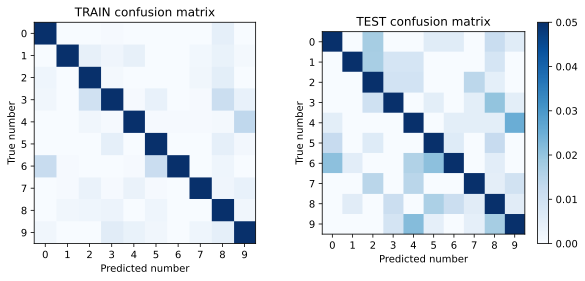

In [23]:
# Training confusion matrix
fig,ax = plt.subplots(1,2,figsize=(10,4))

# confmat during TRAIN
ax[0].imshow(trainConf,'Blues',vmax=.05)
ax[0].set_xticks(range(10))
ax[0].set_yticks(range(10))
ax[0].set_title('TRAIN confusion matrix')
ax[0].set_xlabel('True number')
ax[0].set_xlabel('Predicted number')
ax[0].set_ylabel('True number')

# confmat during TEST
a = ax[1].imshow(testConf,cmap='Blues',vmax=.05)
ax[1].set_xticks(range(10))
ax[1].set_yticks(range(10))
ax[1].set_title('TEST confusion matrix')
ax[1].set_xlabel('Predicted number')
ax[1].set_ylabel('True number')

fig.colorbar(a)
plt.show()
